The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


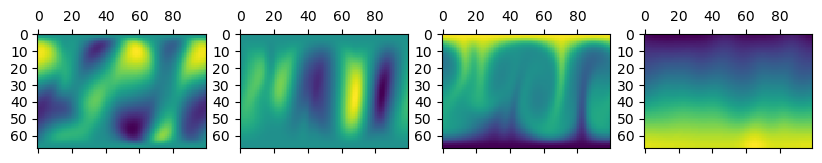

In [499]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import json
import tqdm

import pdes.bc as bc
import pdes.fdc2 as fdc
from conjugate_gradients import CG

torch.set_grad_enabled(False)
torch.set_default_device("cuda")

BOUNDARY_EXTENT = 2

data = json.load(open("data/rbc_data_1.json"))
data = torch.tensor(data)
data = data[::1,...]
P, T, U = data[:,:2,:,:], data[:,2:3,:,:], data[:,3:,:,:]
P = P.sum(dim=1,keepdim=True)

data = torch.cat(( U, T, P ),dim=1)
data = torch.nn.functional.pad(data, [BOUNDARY_EXTENT]*4 )

def project_boundary(X):
    # periodic BC's left and right
    bc.project_periodic( X, dim = -1, side = 0, extent = BOUNDARY_EXTENT)
    bc.project_periodic( X, dim = -1, side = 1, extent = BOUNDARY_EXTENT)

    # velocity (dirichlet, =0)
    bc.project_dirichlet(X[:,:2,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT, val = 0)
    bc.project_dirichlet(X[:,:2,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT, val = 0)
    # temperature (dirichlet, top=2, btm=0)
    bc.project_dirichlet(X[:,2,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT, val = 2)
    bc.project_dirichlet(X[:,2,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT, val = 1)
    # pressure (homogeneous neumann)
    bc.project_homogeneous_neumann(X[:,3,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT)
    bc.project_homogeneous_neumann(X[:,3,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT)

project_boundary(data)
fig, ax = plt.subplots(1,4,figsize=(10,3))
for k in range(4):
    ax[k].matshow( data[-1,k].cpu().numpy() ) 

In [525]:
i = -2
X = data[i,None]
Y = data[i+1,None]
dt = 0.03

dx1 = 2 / 64
dx2 = 2 * torch.pi / 96

grad = fdc.Grad((dx1, dx2), (2,2))


class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # self.L = torch.nn.Conv2d(4,4,kernel_size=(5,5),stride=(1,1),padding="same") # ,bias=True)
        self.L = torch.nn.Conv2d(8,4,kernel_size=(5,5),stride=(1,1),padding="same") # ,bias=False)

    def forward(self, X):
        advection = torch.einsum("bj...,bij... -> bi...", X[:,:2], grad(X))
        Y = torch.cat((advection, X), dim=1)
        Y = self.L(Y)
        # Y = X + dt * (-advection + self.L(X))
        return Y
    
model = Model()
X_rand = X + 0*(torch.rand_like(X)*2-1)*1e-3
def loss(params):
    Y_pred = torch.func.functional_call(model, params, X_rand)
    return (Y_pred - Y).pow(2).sum()
    # return bc.interior(Y_pred - Y, BOUNDARY_EXTENT).pow(2).sum()
params_opt = CG(loss, dict(model.named_parameters()), 10000, threshold=1e-9)
print(loss(params_opt))


tensor(0.2150, device='cuda:0')


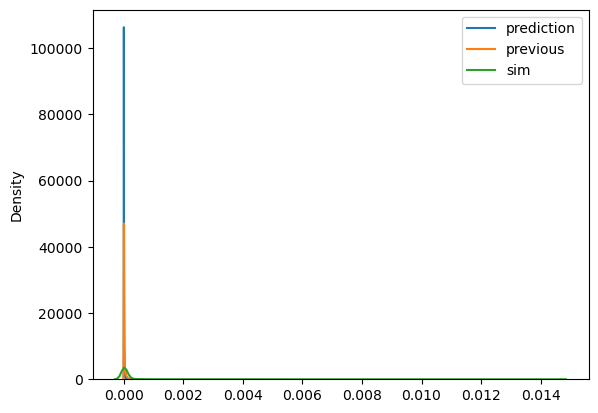

In [524]:
dt_data = 0.09
dt = 0.01
Ra = 1e4
Pr = 0.71
Re = (Ra/Pr)**0.5
nu  = 1 / Re
kappa = 1 / (Ra*Pr)**0.5

lap = fdc.Lap((dx1, dx2), (2, 2))

U = X[:,:2]
T = X[:,2,None]

dU_dx = grad(U)
dT_dx = grad(T)

U_inner_dU_dx = torch.einsum("bj...,bij... -> bi...", U, dU_dx)
U_inner_dT_dx = torch.einsum("bj...,bij... -> bi...", U, dT_dx)
lap_U = lap(U)
lap_T = lap(T)

dU_dt = -U_inner_dU_dx + nu * lap_U + torch.cat((T, torch.zeros_like(T)), dim=1) # - dP_dx[:,0,...]
dT_dt = -U_inner_dT_dx + kappa * lap_T

U_tent = U # U + dt_data * dU_dt
T_tent = T + dt_data * dT_dt
P_tent = X[:,3:,...]
Y_tent = torch.cat((U_tent, T_tent, P_tent), dim=1)
project_boundary(Y_tent)

import seaborn as sns 
Y_pred = torch.func.functional_call(model, params_opt, X)
sns.kdeplot( bc.interior(Y_pred - Y, BOUNDARY_EXTENT).pow(2).flatten().cpu().numpy(), label="prediction" )
sns.kdeplot( bc.interior(X - Y, BOUNDARY_EXTENT).pow(2).flatten().cpu().numpy(), label="previous" )
sns.kdeplot( bc.interior(Y_tent - Y, BOUNDARY_EXTENT).pow(2).flatten().cpu().numpy(), label="sim" )
plt.legend()
plt.show()


# training
# torch.set_grad_enabled(True)
# opt = torch.optim.LBFGS(model.parameters(), lr=1, history_size=200)
# pbar = tqdm.tqdm(range(1000))
# 
# def closure():
#     opt.zero_grad()
#     loss.backward()
#     pbar.set_description(f"loss = {loss.item():.4f}")
#     return loss
# for _ in pbar: opt.step(closure)
# torch.set_grad_enabled(False)

# plt.hist(model.L.weight.data.flatten().cpu().numpy())
# plt.show()

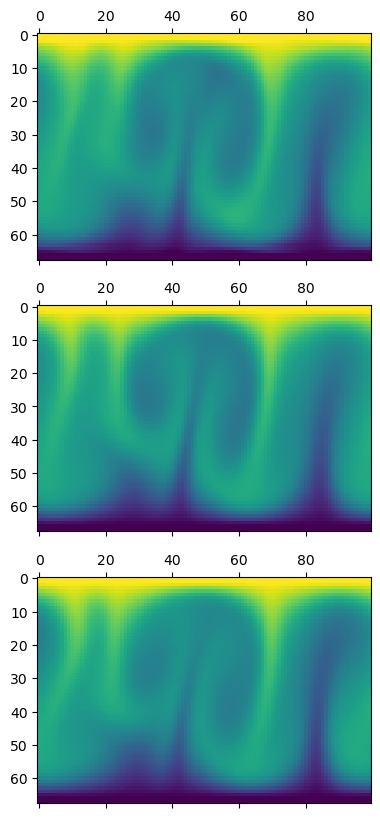

In [478]:
torch.set_grad_enabled(False)
iters = 1
Z = data[-iters-1,None]
for _ in range(iters):
    Z = torch.func.functional_call(model, params_opt, Z)
    project_boundary(Z)

# vmins = [-1, -1, 1, -3]
# vmaxs = [1, 1, 2,  0]
# fig, ax = plt.subplots(2,4,figsize=(20,5))
# for k in range(4):
#     plt.colorbar( ax[0,k].matshow( Z[0,k].cpu().numpy(), vmin = vmins[k], vmax = vmaxs[k] )  )
#     plt.colorbar( ax[1,k].matshow( X[0,k].cpu().numpy(), vmin = vmins[k], vmax = vmaxs[k] )  )

fig, ax = plt.subplots(3, 1,figsize=(5,10))
ax[0].matshow( Z[0,2].cpu().numpy(), vmin = 1, vmax = 2 )
ax[2].matshow( data[-1,2].cpu().numpy(), vmin = 1, vmax = 2 )
ax[1].matshow( data[-iters-1,2].cpu().numpy(), vmin = 1, vmax = 2 )